# Шаг 3. Кластеризация KMeans на доменных шкалах C-BARQ

Вход: артефакты шагов 01–02 (`df_domains`, `df_domains_scaled`, `domain_scaler`).

In [1]:
import json

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

import artifact_loader as my_lib

In [2]:
df_domains = pd.read_csv(my_lib.domain_data_path())
df_domains_scaled = pd.read_csv(my_lib.domain_scaled_data_path())
df_cbarq_clean = pd.read_csv(my_lib.df_cbarq_clean_path())
scaler = joblib.load(my_lib.domain_scaler_path())

with open(my_lib.domain_items_path(), encoding="utf-8") as f:
    DOMAIN_ITEMS = json.load(f)

domain_cols = df_domains.columns.tolist()
assert list(df_domains_scaled.columns) == domain_cols, "domain columns mismatch between raw and scaled"

print(f"rows: {len(df_domains_scaled)}, domains: {len(domain_cols)}")
print(f"scaler: {my_lib.domain_scaler_path()}")

rows: 775, domains: 13
scaler: /Users/l.tereshchenkova/MIPT/startup/notes/barko-docs/analytics/research/artifacts/models/domain_scaler.joblib


### Кластеризация: KMeans + подбор k по silhouette

Перебор `k = 2…8` на `df_domains_scaled`, выбор k с максимальным `silhouette_score`.

Best k by silhouette: 2 (score=0.190)


,silhouette,inertia
k,,
2,0.190,8621.087
3,0.098,7899.395
4,0.074,7576.859
5,0.071,7312.832
6,0.083,6982.597
7,0.076,6753.873
8,0.076,6561.215


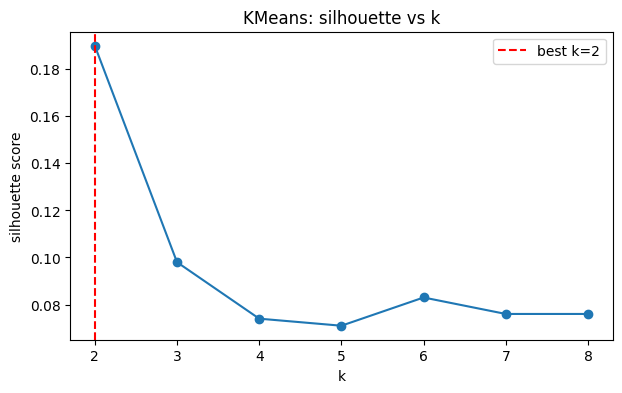


Cluster sizes:


/var/folders/3h/rqpyq0rd7qz5c8g6flkfykh80000gn/T/ipykernel_49647/3747584733.py:40: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_cbarq_clean["cluster"] = cluster_labels


,n_dogs
cluster,
0,244
1,531



Cluster centroids (original 0–4 scale):


,trainability,stranger_directed_aggression,owner_directed_aggression,dog_directed_aggression,stranger_directed_fear,nonsocial_fear,dog_directed_fear,touch_sensitivity,separation_related,excitability,attachment,chasing,energy
cluster_0,1.42,0.95,0.36,1.81,1.34,1.49,1.36,0.93,1.00,2.59,2.87,2.61,2.06
cluster_1,1.50,0.20,0.11,1.09,0.30,0.82,0.56,0.50,0.44,1.80,2.21,2.12,1.51


Saved: /Users/l.tereshchenkova/MIPT/startup/notes/barko-docs/analytics/research/artifacts/csv/clusters/df_domains_kmeans.csv — 775 rows, 14 columns


In [3]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

K_RANGE = range(2, 9)
RANDOM_STATE = 42
X = df_domains_scaled[domain_cols].values

silhouette_rows = []
models = {}

for k in K_RANGE:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init="auto")
    labels = km.fit_predict(X)
    sil = silhouette_score(X, labels)
    silhouette_rows.append({"k": k, "silhouette": sil, "inertia": km.inertia_})
    models[k] = (km, labels)

silhouette_df = pd.DataFrame(silhouette_rows).set_index("k").round(3)
best_k = int(silhouette_df["silhouette"].idxmax())
kmeans_model, cluster_labels = models[best_k]

print(f"Best k by silhouette: {best_k} (score={silhouette_df.loc[best_k, 'silhouette']:.3f})")
display(silhouette_df)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(silhouette_df.index, silhouette_df["silhouette"], marker="o")
ax.axvline(best_k, color="red", linestyle="--", label=f"best k={best_k}")
ax.set_xlabel("k")
ax.set_ylabel("silhouette score")
ax.set_title("KMeans: silhouette vs k")
ax.set_xticks(list(K_RANGE))
ax.legend()
plt.show()

# idempotent re-run: cluster не должен попадать в матрицу доменов
df_domains = df_domains.drop(columns=["cluster"], errors="ignore")
df_cbarq_clean = df_cbarq_clean.drop(columns=["cluster"], errors="ignore")

df_domains["cluster"] = cluster_labels
df_cbarq_clean["cluster"] = cluster_labels

print("\nCluster sizes:")
display(df_domains["cluster"].value_counts().sort_index().to_frame("n_dogs"))

centroids_scaled = pd.DataFrame(
    kmeans_model.cluster_centers_,
    index=[f"cluster_{i}" for i in range(best_k)],
    columns=domain_cols,
)
centroids_raw = pd.DataFrame(
    scaler.inverse_transform(kmeans_model.cluster_centers_),
    index=centroids_scaled.index,
    columns=domain_cols,
)

print("\nCluster centroids (original 0–4 scale):")
display(centroids_raw.round(2))

# export cluster labels
kmeans_export = df_domains.copy()
kmeans_export = kmeans_export.rename(columns={"cluster": "cluster_kmeans"})
out = my_lib.kmeans_out_path()
out.parent.mkdir(parents=True, exist_ok=True)
kmeans_export.to_csv(out, index=False)
print(f"Saved: {out} — {kmeans_export.shape[0]} rows, {kmeans_export.shape[1]} columns")


### Визуализация кластеров

- Heatmap центроидов по доменам C-BARQ (шкала 0–4)
- Post-hoc: распределение `breed_group` и доля `is_mixed` по кластерам

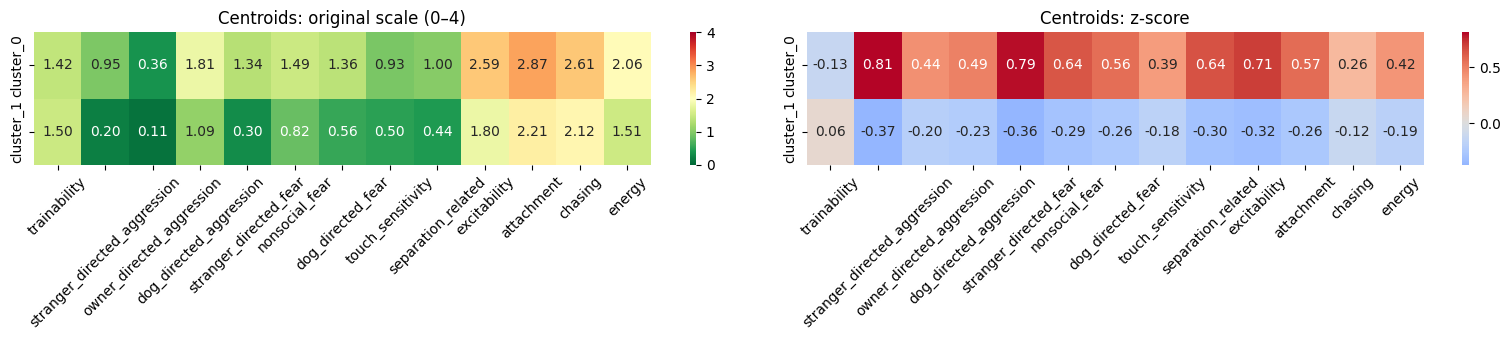

=== is_mixed by cluster (row %) ===


is_mixed,purebred,mixed
cluster,,
0,0.533,0.467
1,0.655,0.345



=== breed_group by cluster (row %) ===


breed_group,companion_toy,gundog,herding,mixed,molosser,other,pinscher_schnauzer,scenthound,sighthound,spitz_nordic,terrier,working
cluster,,,,,,,,,,,,
0,0.082,0.090,0.102,0.467,0.049,0.016,0.029,0.033,0.004,0.041,0.078,0.008
1,0.049,0.269,0.098,0.345,0.092,0.019,0.006,0.019,0.011,0.047,0.028,0.017


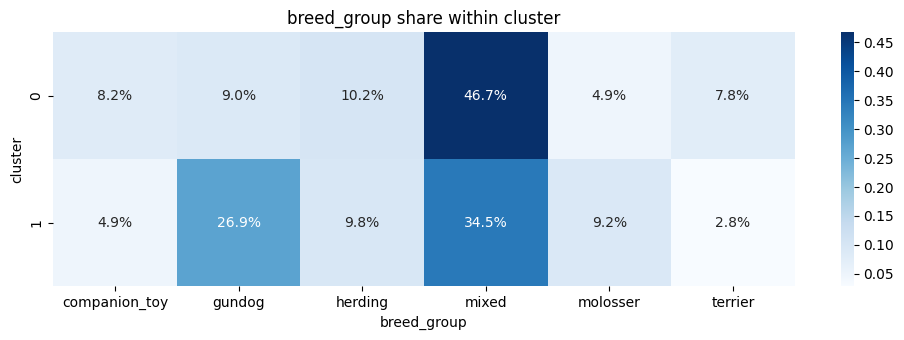


=== Cluster profile summary ===


,cluster,n,is_mixed_pct,top_breed_group,top_breed_group_pct,top2_breed_group,top3_breed_group
0,0,244,0.467,mixed,0.467,herding,gundog
1,1,531,0.345,mixed,0.345,gundog,herding


In [4]:
# --- Heatmap центроидов ---
fig, axes = plt.subplots(1, 2, figsize=(16, max(3.5, best_k * 0.8)))

sns.heatmap(
    centroids_raw,
    annot=True,
    fmt=".2f",
    cmap="RdYlGn_r",
    vmin=0,
    vmax=4,
    ax=axes[0],
)
axes[0].set_title("Centroids: original scale (0–4)")
axes[0].tick_params(axis="x", rotation=45)

sns.heatmap(
    centroids_scaled,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    ax=axes[1],
)
axes[1].set_title("Centroids: z-score")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

# --- Post-hoc: breed_group / is_mixed ---
breed_group_cols = [c for c in df_cbarq_clean.columns if c.startswith("breed_group_")]
df_posthoc = df_cbarq_clean[["cluster", "is_mixed"] + breed_group_cols].copy()

if breed_group_cols:
    df_posthoc["breed_group"] = (
        df_posthoc[breed_group_cols]
        .idxmax(axis=1)
        .str.removeprefix("breed_group_")
    )
    no_group = df_posthoc[breed_group_cols].sum(axis=1) == 0
    df_posthoc.loc[no_group, "breed_group"] = "unknown"
else:
    df_posthoc["breed_group"] = "unknown"

print("=== is_mixed by cluster (row %) ===")
display(
    pd.crosstab(df_posthoc["cluster"], df_posthoc["is_mixed"], normalize="index")
    .round(3)
    .rename(columns={0: "purebred", 1: "mixed"})
)

print("\n=== breed_group by cluster (row %) ===")
breed_ct = pd.crosstab(df_posthoc["cluster"], df_posthoc["breed_group"], normalize="index")
display(breed_ct.round(3))

# heatmap только для групп, встречающихся хотя бы в 5% одного из кластеров
active_groups = breed_ct.columns[(breed_ct.max(axis=0) >= 0.05)]
if len(active_groups) > 0:
    fig, ax = plt.subplots(figsize=(10, max(3.5, best_k * 0.6)))
    sns.heatmap(breed_ct[active_groups], annot=True, fmt=".1%", cmap="Blues", ax=ax)
    ax.set_title("breed_group share within cluster")
    plt.tight_layout()
    plt.show()

print("\n=== Cluster profile summary ===")
summary_rows = []
for cluster_id in sorted(df_posthoc["cluster"].unique()):
    sub = df_posthoc[df_posthoc["cluster"] == cluster_id]
    top_groups = (
        sub["breed_group"].value_counts(normalize=True).head(3)
        if "breed_group" in sub.columns
        else pd.Series(dtype=float)
    )
    summary_rows.append({
        "cluster": cluster_id,
        "n": len(sub),
        "is_mixed_pct": sub["is_mixed"].mean(),
        "top_breed_group": top_groups.index[0] if len(top_groups) else None,
        "top_breed_group_pct": top_groups.iloc[0] if len(top_groups) else np.nan,
        "top2_breed_group": top_groups.index[1] if len(top_groups) > 1 else None,
        "top3_breed_group": top_groups.index[2] if len(top_groups) > 2 else None,
    })

display(pd.DataFrame(summary_rows).round(3))

### Post-hoc: мета-признаки (не участвовали в кластеризации)

Демография, порода, бинарные флаги — сравнение по кластерам поведения.

Meta features restored: 14


,cluster,dog_age_years,dog_age_months,neutered_spayed,age_at_adoption_years,age_at_adoption_months,owner_age,other_dogs_present,is_mixed,is_brachycephalic,other_aggression_present,other_fear_present,other_excitability_present,dog_sex_Femmina,dog_sex_Maschio
0,0,2,2,0,0,8,42,0,0,0,0,0,0,1,0
1,0,12,8,1,0,3,44,1,0,0,0,0,0,0,1
2,0,6,3,0,0,3,47,0,0,0,1,1,0,0,1
3,0,4,0,1,0,3,31,0,0,0,0,0,0,1,0
4,1,7,10,1,0,2,32,0,1,0,0,1,1,1,0


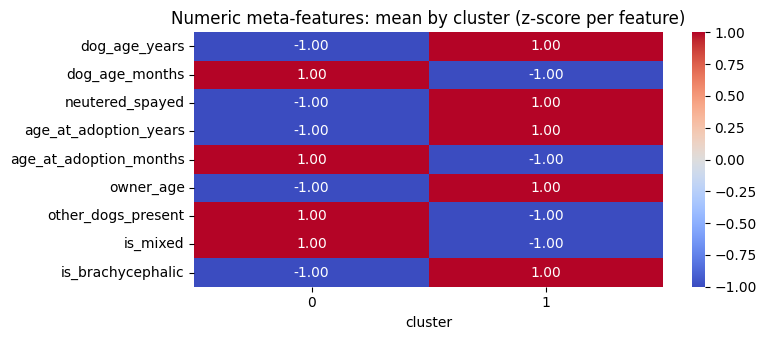

,dog_age_years,dog_age_months,neutered_spayed,age_at_adoption_years,age_at_adoption_months,owner_age,other_dogs_present,is_mixed,is_brachycephalic
cluster,,,,,,,,,
0,5.37,4.71,0.48,0.33,2.96,35.62,0.34,0.47,0.03
1,5.60,4.49,0.49,0.40,2.95,39.10,0.31,0.34,0.06


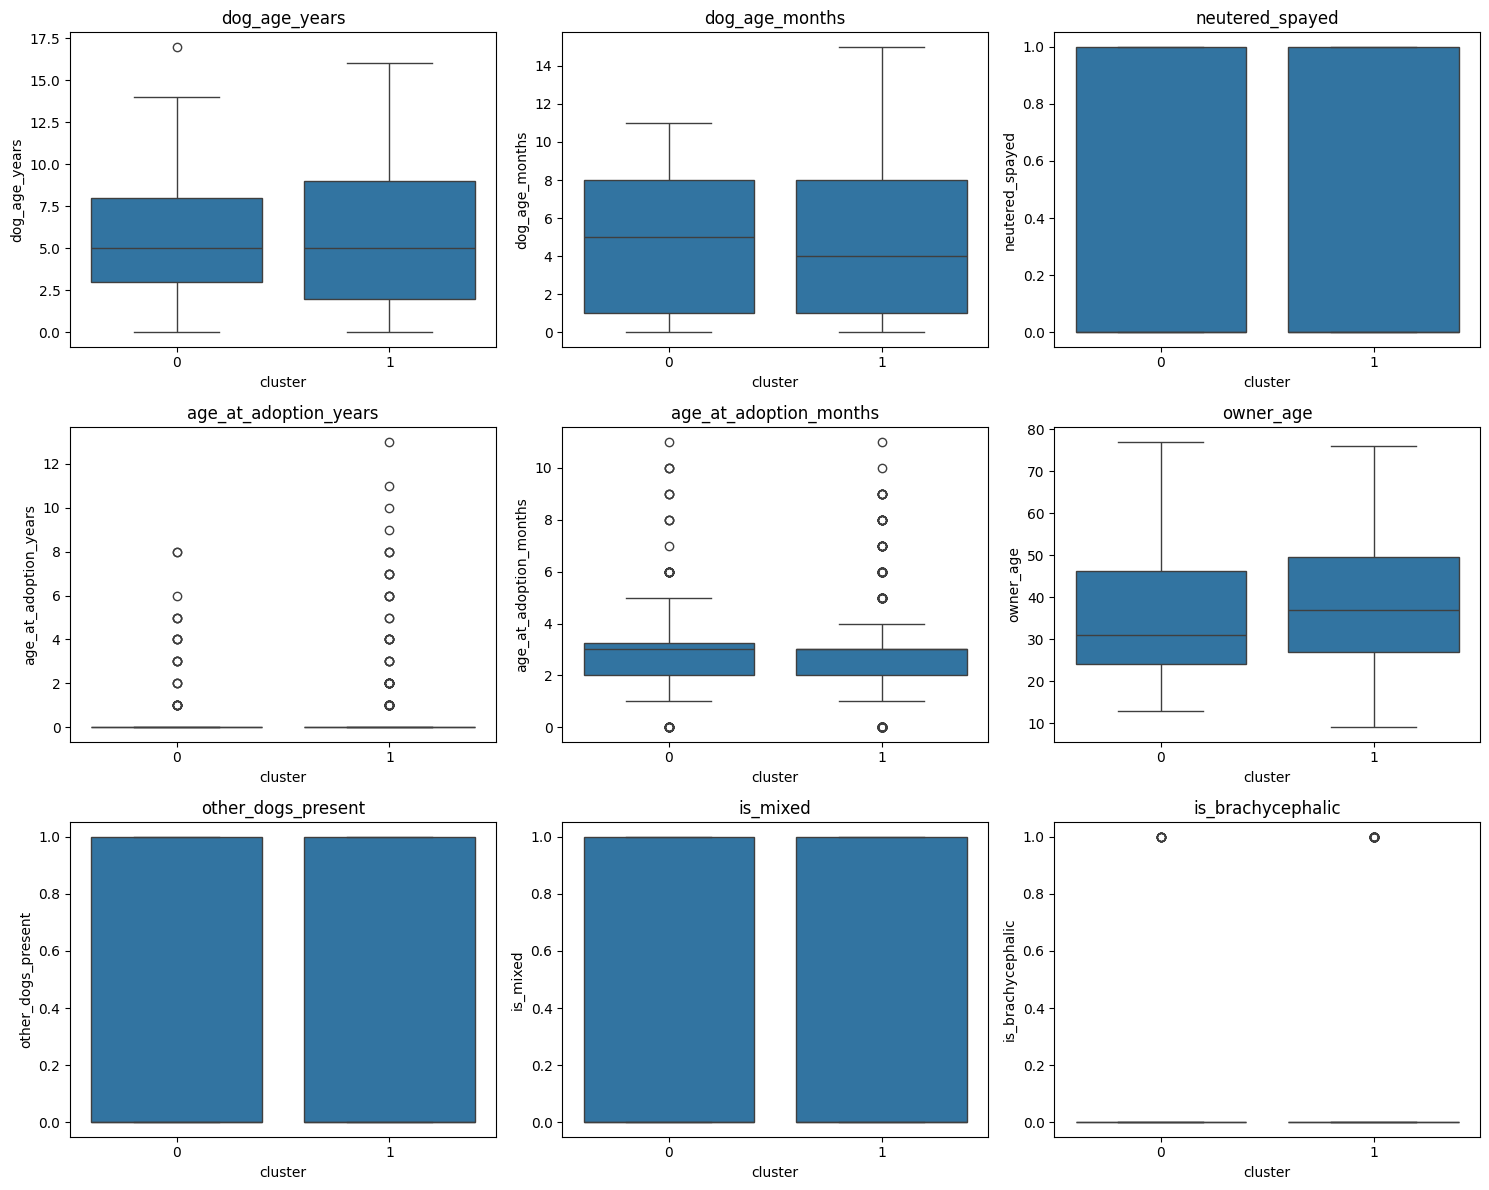

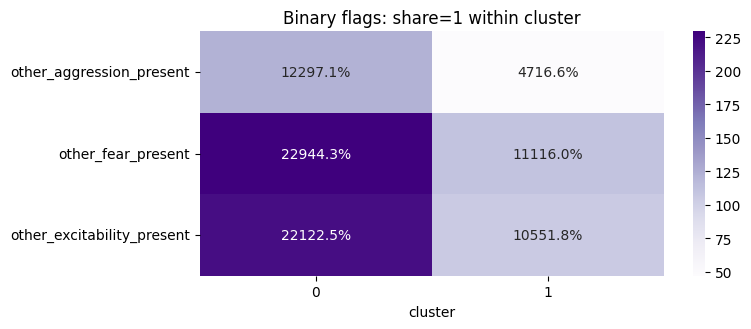

,Femmina,Maschio
cluster,,
0,0.504,0.496
1,0.518,0.482


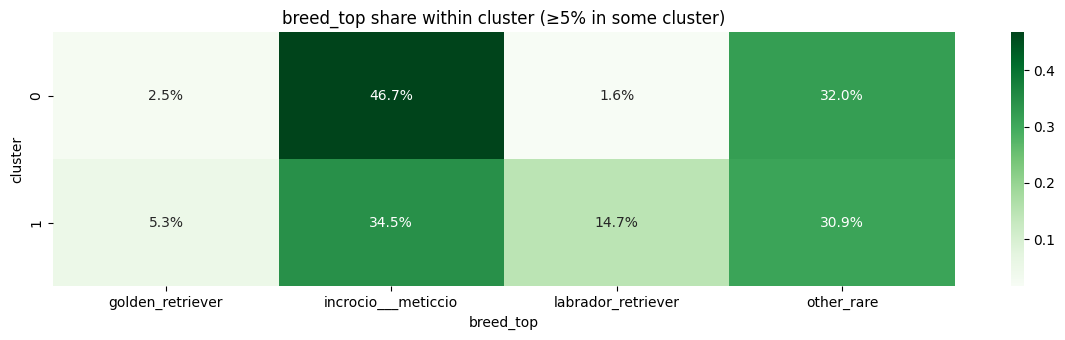

,n,dog_age_years,dog_age_months,neutered_spayed,age_at_adoption_years,age_at_adoption_months,owner_age,other_dogs_present,is_mixed,is_brachycephalic,other_aggression_present,other_fear_present,other_excitability_present
cluster,,,,,,,,,,,,,
0,244,5.373,4.713,0.484,0.328,2.959,35.619,0.336,0.467,0.033,122.971,229.443,221.225
1,531,5.595,4.486,0.493,0.403,2.949,39.104,0.315,0.345,0.060,47.166,111.160,105.518


In [5]:
# Признаки, которые НЕ входили в KMeans (только df_domains_scaled)
META_NUMERIC = [
    c for c in [
        "dog_age_years", "dog_age_months", "neutered_spayed",
        "age_at_adoption_years", "age_at_adoption_months", "owner_age",
        "other_dogs_present", "is_mixed", "is_brachycephalic",
    ]
    if c in df_cbarq_clean.columns
]
META_BINARY = [
    c for c in [
        "other_aggression_present", "other_fear_present", "other_excitability_present",
    ]
    if c in df_cbarq_clean.columns
]
dog_sex_cols = [c for c in df_cbarq_clean.columns if c.startswith("dog_sex_")]
breed_top_cols = [c for c in df_cbarq_clean.columns if c.startswith("breed_top_")]
breed_group_cols = [c for c in df_cbarq_clean.columns if c.startswith("breed_group_")]

df_meta = df_cbarq_clean[["cluster"] + META_NUMERIC + META_BINARY + dog_sex_cols].copy()

print("Meta features restored:", len(META_NUMERIC) + len(META_BINARY) + len(dog_sex_cols))
display(df_meta.head())

# --- 1. Числовые признаки: среднее по кластерам (heatmap) ---
if META_NUMERIC:
    meta_means = df_meta.groupby("cluster")[META_NUMERIC].mean()
    meta_means_z = meta_means.apply(lambda s: (s - s.mean()) / s.std(ddof=0), axis=0)

    fig, ax = plt.subplots(figsize=(8, max(3.5, len(META_NUMERIC) * 0.35)))
    sns.heatmap(meta_means_z.T, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
    ax.set_title("Numeric meta-features: mean by cluster (z-score per feature)")
    plt.tight_layout()
    plt.show()

    display(meta_means.round(2))

# --- 2. Boxplot числовых признаков ---
if META_NUMERIC:
    n_cols = 3
    n_rows = int(np.ceil(len(META_NUMERIC) / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
    axes = np.atleast_1d(axes).flat
    for ax, col in zip(axes, META_NUMERIC):
        sns.boxplot(data=df_meta, x="cluster", y=col, ax=ax)
        ax.set_title(col)
    for ax in axes[len(META_NUMERIC):]:
        ax.axis("off")
    plt.tight_layout()
    plt.show()

# --- 3. Бинарные флаги ---
if META_BINARY:
    binary_rates = df_meta.groupby("cluster")[META_BINARY].mean()
    fig, ax = plt.subplots(figsize=(8, 2.5 + len(META_BINARY) * 0.3))
    sns.heatmap(binary_rates.T, annot=True, fmt=".1%", cmap="Purples", ax=ax)
    ax.set_title("Binary flags: share=1 within cluster")
    plt.tight_layout()
    plt.show()

# --- 4. dog_sex ---
if dog_sex_cols:
    sex_ct = pd.crosstab(df_meta["cluster"], df_meta[dog_sex_cols].idxmax(axis=1), normalize="index")
    sex_ct.columns = [c.removeprefix("dog_sex_") for c in sex_ct.columns]
    display(sex_ct.round(3))

# --- 5. breed_top (топ-породы) ---
if breed_top_cols:
    df_breed_top = df_cbarq_clean[["cluster"] + breed_top_cols].copy()
    df_breed_top["breed_top"] = (
        df_breed_top[breed_top_cols].idxmax(axis=1).str.removeprefix("breed_top_")
    )
    breed_top_ct = pd.crosstab(df_breed_top["cluster"], df_breed_top["breed_top"], normalize="index")
    active_top = breed_top_ct.columns[(breed_top_ct.max(axis=0) >= 0.05)]
    if len(active_top) > 0:
        fig, ax = plt.subplots(figsize=(12, max(3.5, best_k * 0.6)))
        sns.heatmap(breed_top_ct[active_top], annot=True, fmt=".1%", cmap="Greens", ax=ax)
        ax.set_title("breed_top share within cluster (≥5% in some cluster)")
        plt.tight_layout()
        plt.show()

# --- 6. Сводная таблица meta по кластерам ---
meta_summary = df_meta.groupby("cluster").agg(
    n=("cluster", "size"),
    **{col: (col, "mean") for col in META_NUMERIC},
    **{col: (col, "mean") for col in META_BINARY},
)
display(meta_summary.round(3))

### Оценка влияния пропусков (NaN) на доменные шкалы

- Bias: `mean(skipna)` vs imputation медианой по домену
- Симуляция MCAR: случайный dropout на полных строках

In [6]:
from scipy import stats

question_cols = [c for c in df_cbarq_clean.columns if c.startswith("question_")]
miss = df_cbarq_clean[question_cols].isna()

print("=== Item-level ===")
print(f"cell NaN rate: {miss.mean().mean():.2%}")
print(f"rows with any NaN: {miss.any(axis=1).mean():.2%}")
print(f"rows all items complete: {(~miss.any(axis=1)).mean():.2%}")

print("\n=== Domain-level (df_domains from step 3) ===")
print(f"domain score NaN rate: {df_domains.isna().mean().mean():.2%}")
print(f"rows all domains complete: {(~df_domains.isna().any(axis=1)).mean():.1%}")

# --- Bias table: available mean vs median-imputed ---
bias_rows = []
for name, items in DOMAIN_ITEMS.items():
    items = [i for i in items if i in df_cbarq_clean.columns]
    avail = df_cbarq_clean[items].mean(axis=1, skipna=True)
    imputed = df_cbarq_clean[items].fillna(df_cbarq_clean[items].median()).mean(axis=1)
    partial = df_cbarq_clean[items].isna().any(axis=1) & avail.notna()
    diff = avail - imputed
    sd = avail.std()
    bias_rows.append({
        "domain": name,
        "n_partial": int(partial.sum()),
        "MAE": diff.abs().mean(),
        "mean_bias": diff.mean(),
        "MAE_over_SD": diff.abs().mean() / sd if sd else np.nan,
        "cohens_d": diff.mean() / sd if sd else np.nan,
        "r_avail_imputed": avail.corr(imputed),
        "t_p_partial": stats.ttest_1samp(diff[partial], 0).pvalue if partial.sum() >= 2 else np.nan,
    })

bias_df = pd.DataFrame(bias_rows).set_index("domain").round(3)
display(bias_df)

# --- MCAR simulation: random 6% dropout on item-complete rows ---
rng = np.random.default_rng(42)
complete_rows = df_cbarq_clean[question_cols].notna().all(axis=1)
base = df_cbarq_clean.loc[complete_rows, question_cols]
domain_base = {
    name: base[[i for i in items if i in base.columns]].mean(axis=1)
    for name, items in DOMAIN_ITEMS.items()
}

mcar_rows = []
n_sims = 500
dropout_rate = miss.mean().mean()
for _ in range(n_sims):
    sim = base.copy()
    sim = sim.mask(rng.random(sim.shape) < dropout_rate)
    for name, items in DOMAIN_ITEMS.items():
        items = [i for i in items if i in sim.columns]
        sim_score = sim[items].mean(axis=1, skipna=True)
        mcar_rows.append({
            "domain": name,
            "abs_bias": (sim_score - domain_base[name]).abs().mean(),
        })

mcar_df = (
    pd.DataFrame(mcar_rows)
    .groupby("domain")["abs_bias"]
    .agg(MCAR_MAE="mean", MCAR_p95=lambda s: np.percentile(s, 95))
    .round(4)
)
print(f"\n=== MCAR simulation ({n_sims} runs, dropout={dropout_rate:.1%}, n={complete_rows.sum()} complete rows) ===")
display(mcar_df)

summary = bias_df[["MAE", "r_avail_imputed"]].join(mcar_df)
print("\n=== Summary: observed MAE vs simulated MCAR MAE ===")
display(summary.round(3))

=== Item-level ===
cell NaN rate: 3.03%
rows with any NaN: 74.32%
rows all items complete: 25.68%

=== Domain-level (df_domains from step 3) ===
domain score NaN rate: 0.00%
rows all domains complete: 100.0%


,n_partial,MAE,mean_bias,MAE_over_SD,cohens_d,r_avail_imputed,t_p_partial
domain,,,,,,,
trainability,130,0.022,-0.006,0.055,-0.015,0.985,0.016
stranger_directed_aggression,43,0.011,0.011,0.017,0.017,0.993,0.000
owner_directed_aggression,71,0.007,0.007,0.017,0.017,0.994,0.000
dog_directed_aggression,44,0.033,0.002,0.033,0.002,0.984,0.816
stranger_directed_fear,30,0.012,0.012,0.014,0.014,0.994,0.000
nonsocial_fear,80,0.021,0.020,0.030,0.027,0.994,0.000
dog_directed_fear,12,0.010,0.003,0.010,0.003,0.993,0.560
touch_sensitivity,316,0.093,0.093,0.122,0.122,0.953,0.000
separation_related,41,0.012,0.012,0.019,0.019,0.990,0.000



=== MCAR simulation (500 runs, dropout=3.0%, n=199 complete rows) ===


,MCAR_MAE,MCAR_p95
domain,,
attachment,0.0300,0.0409
chasing,0.0265,0.0419
dog_directed_aggression,0.0273,0.0419
dog_directed_fear,0.0178,0.0352
energy,0.0328,0.0486
excitability,0.0265,0.0352
nonsocial_fear,0.0239,0.0329
owner_directed_aggression,0.0054,0.0090
separation_related,0.0173,0.0236



=== Summary: observed MAE vs simulated MCAR MAE ===


,MAE,r_avail_imputed,MCAR_MAE,MCAR_p95
domain,,,,
trainability,0.022,0.985,0.035,0.045
stranger_directed_aggression,0.011,0.993,0.009,0.014
owner_directed_aggression,0.007,0.994,0.005,0.009
dog_directed_aggression,0.033,0.984,0.027,0.042
stranger_directed_fear,0.012,0.994,0.010,0.016
nonsocial_fear,0.021,0.994,0.024,0.033
dog_directed_fear,0.010,0.993,0.018,0.035
touch_sensitivity,0.093,0.953,0.016,0.027
separation_related,0.012,0.990,0.017,0.024
